<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# Clase Práctica: Fundamentos Matemáticos y Computacionales de la Visión por Computador
**Dirigido a:** Físicos, Astrónomos e Ingenieros Físicos

**Duración Estimada:** 1 hora y 30 minutos  

**Diseño Curricular:** Pamela Franco

---

## Estructura Teórica y Objetivos de la Clase
1. **Módulo 1: Procesamiento vs. Análisis de Imágenes** (20 min) - Comprender la imagen como un operador matemático y una matriz cuántica/discreta de intensidades.
2. **Módulo 2: Evolución Óptica y Geométrica** (20 min) - Conectar el teorema de Tales, la perspectiva lineal de Brunelleschi y el plano cartesiano con la proyección de cámaras de sensor digital.
3. **Módulo 3: Laboratorio y Ejercicios Prácticos en Python** (50 min) - Manipulación tensorial y transformaciones aplicadas a datos ópticos reales.

---

In [ ]:
# ==========================================
# CELDA DE CONFIGURACIÓN INICIAL (EJECUTAR)
# ==========================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO

print("Instalando dependencias y entorno listo.")

Instalando dependencias y entorno listo.


---
## Módulo 1: Definiciones Formales y el Paradigma del Flujo Óptico

En las ciencias físicas y astronómicas, una imagen es la captura de un campo de radiación electromagnética discretizado en el espacio mediante un sensor (CCD o CMOS). Dependiendo del objetivo computacional, clasificamos los algoritmos en tres grandes grupos:

1. **Procesamiento de Imágenes (Image Processing):** Un algoritmo toma una imagen como entrada $I(x,y)$ y devuelve otra imagen $I'(x,y)$ como salida. Su fin suele ser la restauración, filtrado o mejora del contraste (ej. eliminación de ruido cósmico).
2. **Análisis de Imágenes (Image Analysis):** Algoritmos que toman una imagen como entrada y extraen mediciones cuantitativas, descriptores geométricos o decisiones discretas (ej. fotometría de apertura en estrellas).
3. **Visión por Computador (Computer Vision):** El campo teórico y metodológico enfocado en la adquisición, procesamiento y comprensión profunda de datos bidimensionales y de alta dimensión del mundo real para producir información simbólica y decisiones automatizadas ("Dotar a las máquinas con la capacidad de ver").

### Representación Matemática de un Sistema de Visión:
$$\text{Objeto Real} \xrightarrow{\text{Adquisición Óptica}} \text{Imagen} \xrightarrow{\text{Procesamiento (Filtros)}} \text{Segmentación} \xrightarrow{\text{Extracción de Atributos}} \text{Clasificación / Decisión}$$

---
## Módulo 2: Historia, Geometría Analítica y la Transición al Píxel

Para un físico, la historia de la Visión por Computador está íntimamente ligada a la evolución de la **óptica geométrica** y el modelamiento del espacio-tiempo:

* **Grecia Antigua (Tales y Euclides):** El *Teorema del Intercepto* o de los triángulos similares de Tales sentó las bases para relacionar objetos del mundo real y sus proyecciones en un plano.
* **El Renacimiento (Brunelleschi y Da Vinci):** La invención de la máquina de perspectiva y espejos parabólicos para simular proyecciones cónicas lineales en un lienzo bidimensional.
* **René Descartes (1596-1650):** El nacimiento de la *Geometría Analítica*. Introducir el plano cartesiano $(X, Y, Z)$ permitió por primera vez modelar la geometría del espacio tridimensional mediante ecuaciones algebraicas lineales susceptibles de ser calculadas por algoritmos.
* **Evolución del Sensor (De Niépce a Steve Sasson - 1975):** La transición desde la transferencia química de fotones (película fotográfica) a la discretización digital de la carga eléctrica. La primera cámara digital (Kodak, 1975) capturaba una resolución tensorial de solo $100 \times 100$ píxeles en blanco y negro, almacenando la carga en una cinta magnética por 23 segundos.

Hoy en día, una imagen digital no es más que un **tensor de orden 2 (grises) o 3 (color)** que representa la irradiancia integrada en un área infinitesimal de silicio.

---
# Laboratorio Práctico en Python

### Ejercicio 1: Generación Sintética de un Patrón de Difracción de Rendija Única
Como físicos y astrónomos, a menudo trabajamos con simulaciones. Vamos a generar una imagen sintética matemática pura basándonos en la teoría ondulatoria de la luz e interpretándola en el dominio analítico de la visión por computador.

La intensidad de la difracción de Fraunhofer para una rendija de ancho $a$ viene dada por:
$$I(\theta) = I_0 \left( \frac{\sin(\beta)}{\beta} \right)^2$$ donde $\beta = \frac{\pi a}{\lambda} \sin(\theta)$.

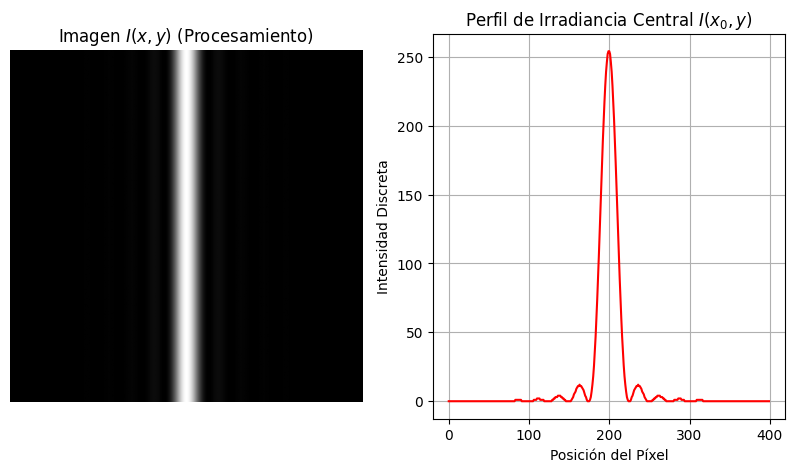

In [ ]:
# EJERCICIO 1: Código Python

def generar_patron_difraccion(shape=(400, 400), I0=255, a=1e-4, lmbda=632.8e-9):
    """
    Genera una matriz que simula un patrón de difracción óptico real.
    """
    rows, cols = shape
    imagen = np.zeros((rows, cols), dtype=np.float32)

    # Centro de la imagen
    cx = cols // 2

    # Mapear las columnas a ángulos simulados (-theta_max a +theta_max)
    theta_max = 0.05
    angles = np.linspace(-theta_max, theta_max, cols)

    for j, theta in enumerate(angles):
        if theta == 0:
            intensidad = I0
        else:
            beta = (np.pi * a / lmbda) * np.sin(theta)
            intensidad = I0 * (np.sin(beta) / beta)**2

        # Asignar la intensidad a toda la columna (línea de difracción)
        imagen[:, j] = intensidad

    # Normalizar a rango estándar de imagen de 8 bits [0, 255]
    imagen = np.clip(imagen, 0, 255).astype(np.uint8)
    return imagen

# Generar y visualizar
patron_optico = generar_patron_difraccion()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen $I(x,y)$ (Procesamiento)")
plt.imshow(patron_optico, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Perfil de Irradiancia Central $I(x_0, y)$")
plt.plot(patron_optico[200, :], color='red')
plt.xlabel("Posición del Píxel")
plt.ylabel("Intensidad Discreta")
plt.grid(True)
plt.show()

### Ejercicio 2: Procesamiento vs Análisis de Imágenes (Segmentación de Máximos)
**Desafío del Módulo:** Aplica un umbral matemático (Thresholding) para extraer cuántos máximos secundarios de energía luminosa son detectables por encima de un nivel crítico de ruido (Simulación de Análisis de Imágenes).

Resultado del Análisis: Se han detectado 1 franjas de energía críticas.


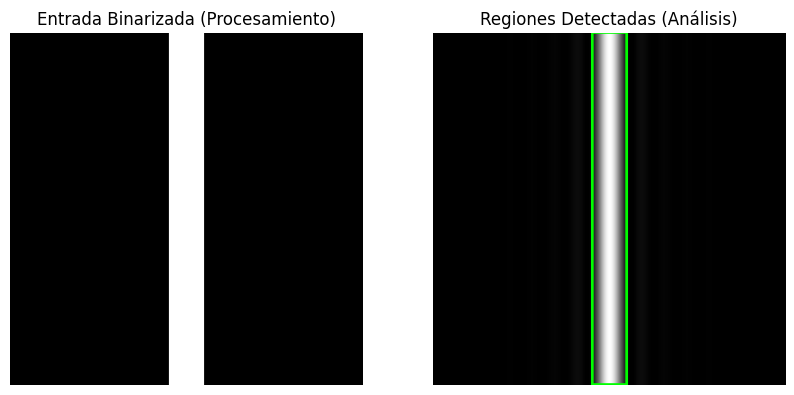

In [ ]:
# EJERCICIO 2: Código Python

# Paso A: Procesamiento de Imágenes (Filtro Umbral Binarizado)
# Definimos un umbral de intensidad crítica (por ejemplo, 15 sobre 255)
umbral_critico = 15
_, imagen_binaria = cv2.threshold(patron_optico, umbral_critico, 255, cv2.THRESH_BINARY)

# Paso B: Análisis de Imágenes (Extracción de Atributos Científicos)
# Encontraremos los contornos de las regiones de alta energía electromagnética
contornos, _ = cv2.findContours(imagen_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Resultado del Análisis: Se han detectado {len(contornos)} franjas de energía críticas.")

# Graficar el resultado del análisis
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Entrada Binarizada (Procesamiento)")
plt.imshow(imagen_binaria, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Regiones Detectadas (Análisis)")
resultado_color = cv2.cvtColor(patron_optico, cv2.COLOR_GRAY2RGB)
cv2.drawContours(resultado_color, contornos, -1, (0, 255, 0), 2)
plt.imshow(resultado_color)
plt.axis('off')
plt.show()

### Ejercicio 3: Calibración y Simulación del Ruido de Sensor Cuántico (Shot Noise)
En instrumentación astrofísica o física experimental, las mediciones están corrompidas por el ruido de Poisson (Shot Noise), debido a la naturaleza discreta de la llegada de los fotones al detector.

Vamos a modelar el efecto que sufrió la primera cámara digital de 1975 o un detector CCD astronómico de baja ganancia criogénica.

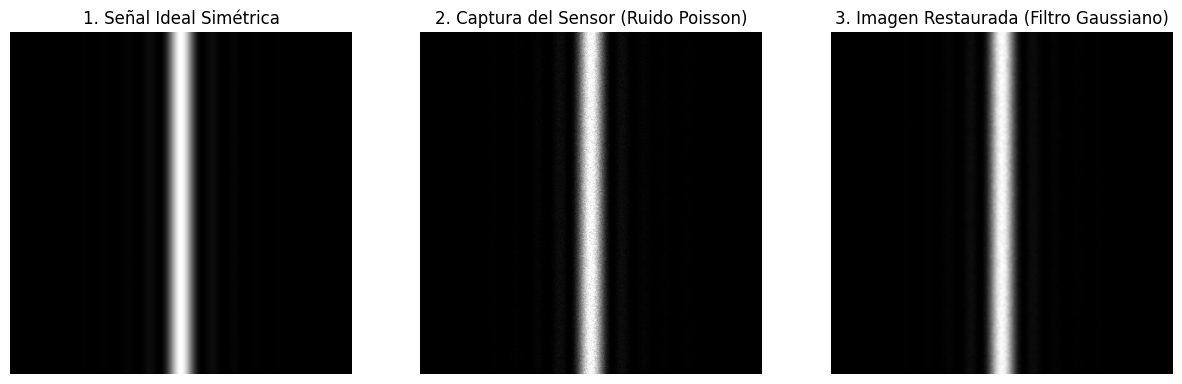

In [ ]:
# EJERCICIO 3: Código Python

def aplicar_ruido_poisson(imagen_base):
    """
    Aplica ruido de Poisson simulando la naturaleza corpuscular de los fotones sobre un sensor CCD.
    """
    # El ruido de Poisson depende del valor esperado del píxel (número de fotones)
    # Convertimos temporalmente a flotante para evitar desbordamientos
    vals = len(np.unique(imagen_base))
    vals = 2 ** np.ceil(np.log2(vals))

    # Generación estadística basada en distribución de Poisson
    ruidosa = np.random.poisson(imagen_base.astype(float))
    ruidosa = np.clip(ruidosa, 0, 255).astype(np.uint8)
    return ruidosa

# Aplicar ruido al patrón geométrico previo
imagen_con_ruido = aplicar_ruido_poisson(patron_optico)

# Procesamiento de restauración básica para astrofísicos (Filtro Gaussiano para suavizar frentes de onda)
imagen_filtrada = cv2.GaussianBlur(imagen_con_ruido, (5, 5), 0)

# Renderizado del pipeline experimental completo
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("1. Señal Ideal Simétrica")
plt.imshow(patron_optico, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Captura del Sensor (Ruido Poisson)")
plt.imshow(imagen_con_ruido, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Imagen Restaurada (Filtro Gaussiano)")
plt.imshow(imagen_filtrada, cmap='gray')
plt.axis('off')
plt.show()

---
## Ejercicio de Discusión en Grupo (Notebook Open-Ended)
**Para los Astrónomos y Físicos de la clase:**
Observa el perfil de intensidad afectado por el ruido de Poisson.
1. ¿Cómo afecta la fluctuación cuántica estadistica a la capacidad del algoritmo en el *Ejercicio 2* para encontrar de forma exacta la posición espacial central de los máximos secundarios?
2. Diseña matemáticamente un método basado en mínimos cuadrados para ajustar una función teórica Sinc cuadrada sobre los datos ruidosos obtenidos del sensor.